# S7C-D2: robust causal retarded-bearing EKF

## tl;dr

This is a held-out, paired bearing-level benchmark, not a manoeuvre model. On strong outliers the combined consensus+NIS variant raises final validity from 0.46/0.56 to 1.00/1.00 and reduces position RMSE from 8.47/6.00 m to 0.81/0.60 m. On mixed profiles it raises validity from 0.70/0.77 to 1.00/1.00 and reduces RMSE from 7.33/5.36 m to 0.95/0.70 m. However, rare contaminated six-event initializations under mild 5 degree outliers cause combined RMSE 13.32/40.55 m despite much smaller P95 1.75/8.67 m. Thresholds were not retuned after this result.

## Context & Methods

### Key Assumptions

The state is strict constant velocity with Q=0 in a homogeneous stationary medium. Four variants share each event stream: unchanged C1, consensus initialization only, NIS gate only, and both. Consensus uses only spherical tangent residuals, declared covariance and observable event IDs. The update gate is chi-square(2, 0.99)=9.21034; this is only a local Gaussian benchmark. Outlier truth is evaluator-only. The 200 base sequences are independent; variants, profiles, events and epochs within a base sequence are dependent.

In [1]:
from pathlib import Path
import csv
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'
RUN_FULL = False  # True reruns all 200 independent base blocks.
if RUN_FULL:
    from validation.retarded_ekf_robust_study import run_retarded_ekf_robust_study
    run_retarded_ekf_robust_study(RESULTS, sequence_count=100, base_seed=20260912, workers=8, progress=True)
plt.rcParams.update({'figure.figsize': (10, 4.8), 'axes.grid': True, 'grid.alpha': 0.25})

## Data

Default mode reviews the committed outputs from `results/`; it is explicitly not a fresh Monte Carlo run. Set `RUN_FULL=True` to regenerate them from the frozen protocol.

In [2]:
def load_csv(name):
    with (RESULTS / name).open(encoding='utf-8', newline='') as handle:
        return list(csv.DictReader(handle))

sequence_rows = load_csv('retarded_ekf_robust_sequence_results.csv')
summary_rows = load_csv('retarded_ekf_robust_profile_summary.csv')
seed_rows = load_csv('retarded_ekf_robust_seed_provenance.csv')
assert (len(sequence_rows), len(summary_rows), len(seed_rows)) == (7200, 72, 200)
print({'sequence_rows': len(sequence_rows), 'profile_rows': len(summary_rows), 'seed_rows': len(seed_rows)})

{'sequence_rows': 7200, 'profile_rows': 72, 'seed_rows': 200}


## Results

In [3]:
selected = []
for row in summary_rows:
    if row['profile'] in {'nominal', 'outlier_mild', 'outlier_strong', 'mixed'} and row['variant'] in {'c1_baseline', 'robust_combined'}:
        selected.append({
            'geometry': row['geometry'], 'profile': row['profile'], 'variant': row['variant'],
            'valid': round(float(row['final_valid_fraction']), 3),
            'position_rmse_m': round(float(row['conditional_position_rmse_m']), 3),
            'position_p95_m': round(float(row['conditional_position_p95_m']), 3),
            'unconditional_coverage': round(float(row['unconditional_valid_and_covered_fraction']), 3),
        })
selected

[{'geometry': 'informative',
  'profile': 'nominal',
  'variant': 'c1_baseline',
  'valid': 1.0,
  'position_rmse_m': 0.759,
  'position_p95_m': 1.4,
  'unconditional_coverage': 0.92},
 {'geometry': 'informative',
  'profile': 'nominal',
  'variant': 'robust_combined',
  'valid': 1.0,
  'position_rmse_m': 0.77,
  'position_p95_m': 1.473,
  'unconditional_coverage': 0.9},
 {'geometry': 'informative',
  'profile': 'outlier_mild',
  'variant': 'c1_baseline',
  'valid': 1.0,
  'position_rmse_m': 1.741,
  'position_p95_m': 3.549,
  'unconditional_coverage': 0.21},
 {'geometry': 'informative',
  'profile': 'outlier_mild',
  'variant': 'robust_combined',
  'valid': 1.0,
  'position_rmse_m': 13.321,
  'position_p95_m': 1.747,
  'unconditional_coverage': 0.89},
 {'geometry': 'informative',
  'profile': 'outlier_strong',
  'variant': 'c1_baseline',
  'valid': 0.46,
  'position_rmse_m': 8.472,
  'position_p95_m': 14.114,
  'unconditional_coverage': 0.0},
 {'geometry': 'informative',
  'profile': 

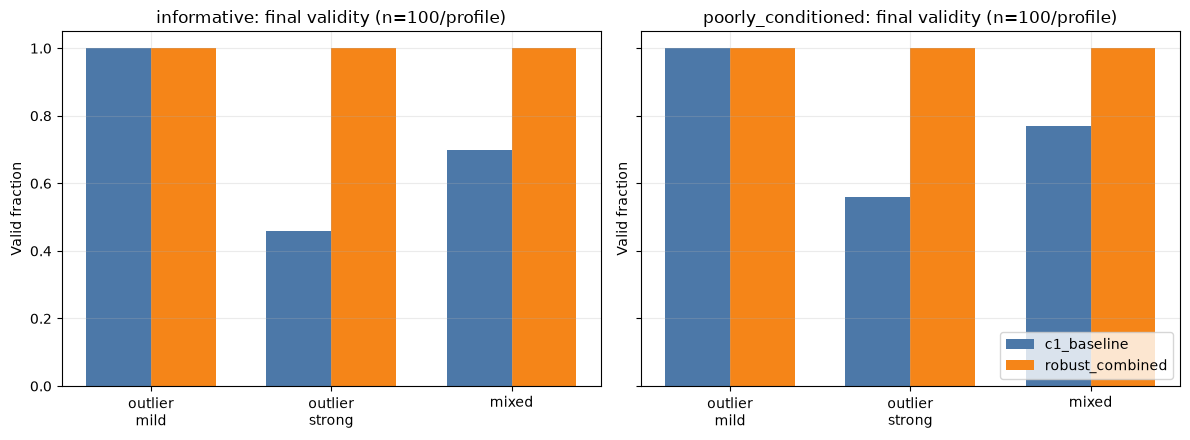

In [4]:
profiles = ['outlier_mild', 'outlier_strong', 'mixed']
variants = ['c1_baseline', 'robust_combined']
colors = {'c1_baseline': '#4C78A8', 'robust_combined': '#F58518'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axis, geometry in zip(axes, ['informative', 'poorly_conditioned']):
    x = np.arange(len(profiles)); width = 0.36
    for offset, variant in enumerate(variants):
        values = [float(next(r for r in summary_rows if r['geometry']==geometry and r['profile']==p and r['variant']==variant)['final_valid_fraction']) for p in profiles]
        axis.bar(x + (offset-0.5)*width, values, width, label=variant, color=colors[variant])
    axis.set_title(f'{geometry}: final validity (n=100/profile)')
    axis.set_xticks(x, [p.replace('_', '\n') for p in profiles])
    axis.set_ylim(0, 1.05); axis.set_ylabel('Valid fraction')
axes[1].legend(loc='lower right'); fig.tight_layout(); plt.show()

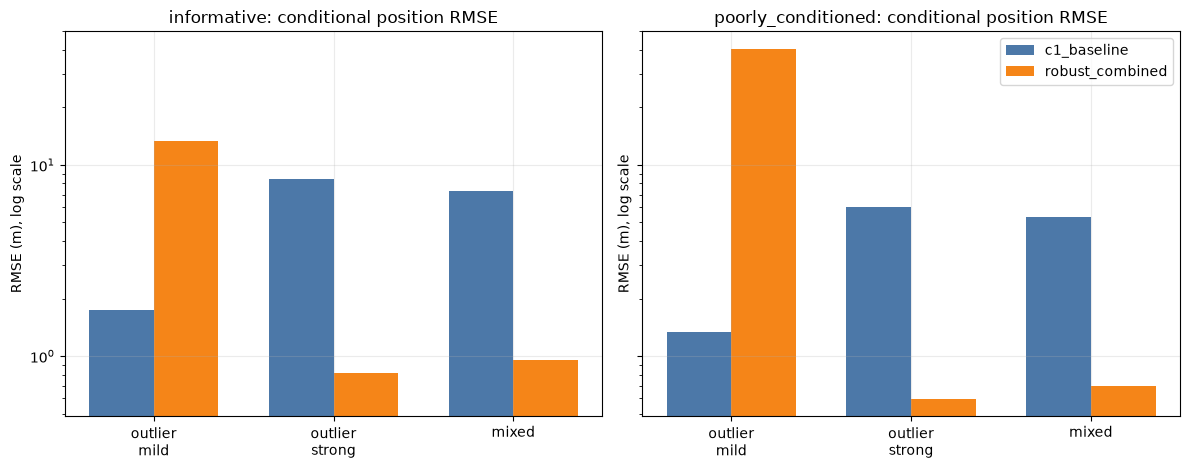

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for axis, geometry in zip(axes, ['informative', 'poorly_conditioned']):
    x = np.arange(len(profiles)); width = 0.36
    for offset, variant in enumerate(variants):
        values = [float(next(r for r in summary_rows if r['geometry']==geometry and r['profile']==p and r['variant']==variant)['conditional_position_rmse_m']) for p in profiles]
        axis.bar(x + (offset-0.5)*width, values, width, label=variant, color=colors[variant])
    axis.set_yscale('log'); axis.set_title(f'{geometry}: conditional position RMSE')
    axis.set_xticks(x, [p.replace('_', '\n') for p in profiles]); axis.set_ylabel('RMSE (m), log scale')
axes[1].legend(); fig.tight_layout(); plt.show()

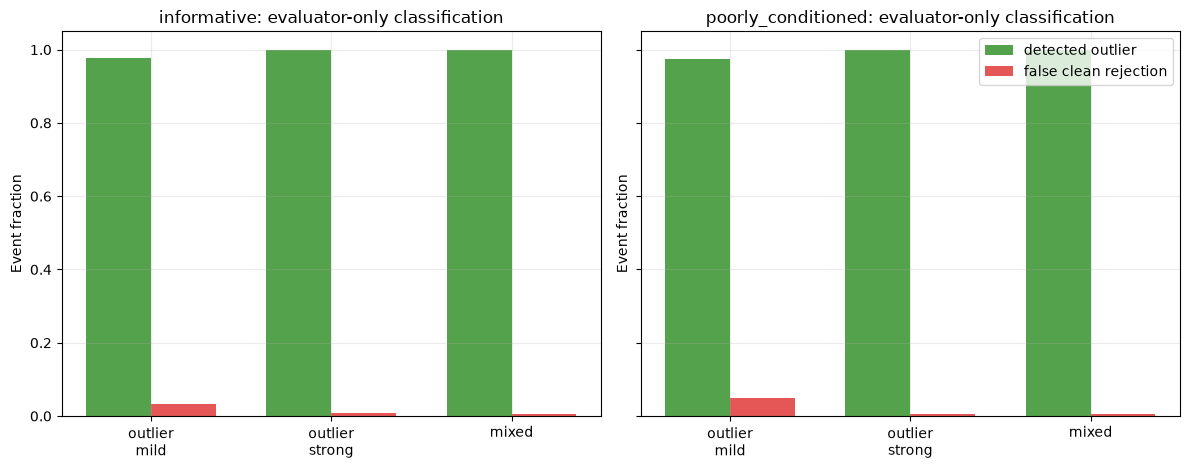

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for axis, geometry in zip(axes, ['informative', 'poorly_conditioned']):
    rows = [next(r for r in summary_rows if r['geometry']==geometry and r['profile']==p and r['variant']=='robust_combined') for p in profiles]
    detected = [float(r['detected_outlier_event_fraction']) for r in rows]
    false_clean = [float(r['false_rejected_clean_event_fraction']) for r in rows]
    x = np.arange(len(profiles)); width = 0.36
    axis.bar(x-width/2, detected, width, label='detected outlier', color='#54A24B')
    axis.bar(x+width/2, false_clean, width, label='false clean rejection', color='#E45756')
    axis.set_title(f'{geometry}: evaluator-only classification')
    axis.set_xticks(x, [p.replace('_', '\n') for p in profiles]); axis.set_ylabel('Event fraction'); axis.set_ylim(0, 1.05)
axes[1].legend(); fig.tight_layout(); plt.show()

## Data-quality checks

In [7]:
from validation.retarded_ekf_robust_study import audit_robust_results
audit = audit_robust_results(sequence_rows, summary_rows, seed_rows, sequence_count=100)
assert all(row['outlier_truth_used_by_estimator'] == 'False' for row in sequence_rows)
assert all(row['covariance_after_selection_assumed_calibrated'] == 'False' for row in summary_rows)
audit

{'sequence_row_count': 7200,
 'summary_row_count': 72,
 'seed_row_count': 200,
 'unique_mechanism_seed_count': 1200}

## Takeaways

The combined mechanism is compelling for the frozen strong and mixed profiles, where both reliable initialization and update rejection are needed. NIS gating alone cannot repair a contaminated initialization and can preserve a bad prior by rejecting later clean observations. The mild-outlier RMSE/P95 divergence exposes rare catastrophic tails: the current six-inlier consensus is not a complete solution. Clean nominal false-rejection rates are 0.82% and 0.71%, with small RMSE changes and no validity loss. Covariance coverage is empirical and is not declared calibrated after selection. A next data step should evaluate a separately designed redundant-initialization rule on another held-out seed; this notebook does not retune the accepted thresholds.